In [1]:
import sys
base_path = '/mnt/home/blyo1/diva'
if base_path not in sys.path:
    sys.path.append(base_path)

import torch
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision
from torchvision import transforms
import matplotlib.pyplot as plt
import matplotlib
from tqdm import tqdm
from base_utils.base_utils import *
import os
%matplotlib inline
import argparse
import json
import gdown
import zipfile
import io

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
# reload jupyter magic
%load_ext autoreload
%autoreload 2

cuda


In [14]:
data_root = 'datasets/celeba'
# Path to folder with the dataset
dataset_folder = f'{data_root}/images'

# URL for the CelebA dataset
url = 'https://drive.google.com/uc?export=download&id=0B7EVK8r0v71pZjFTYXZWM3FlRnM'
# Path to download the dataset to
download_path = f'{data_root}/img_align_celeba.zip'

# Create required directories 
if not os.path.exists(data_root):
  os.makedirs(data_root)
  os.makedirs(dataset_folder)

download = False

if download:
    # Download the dataset from google drive
    gdown.download(url, download_path, quiet=False)

In [15]:
# unzip the dataset
if not os.path.exists(dataset_folder):
    with zipfile.ZipFile(download_path, 'r') as zip_ref:
        zip_ref.extractall(dataset_folder)

Number of images in the dataset: 202599


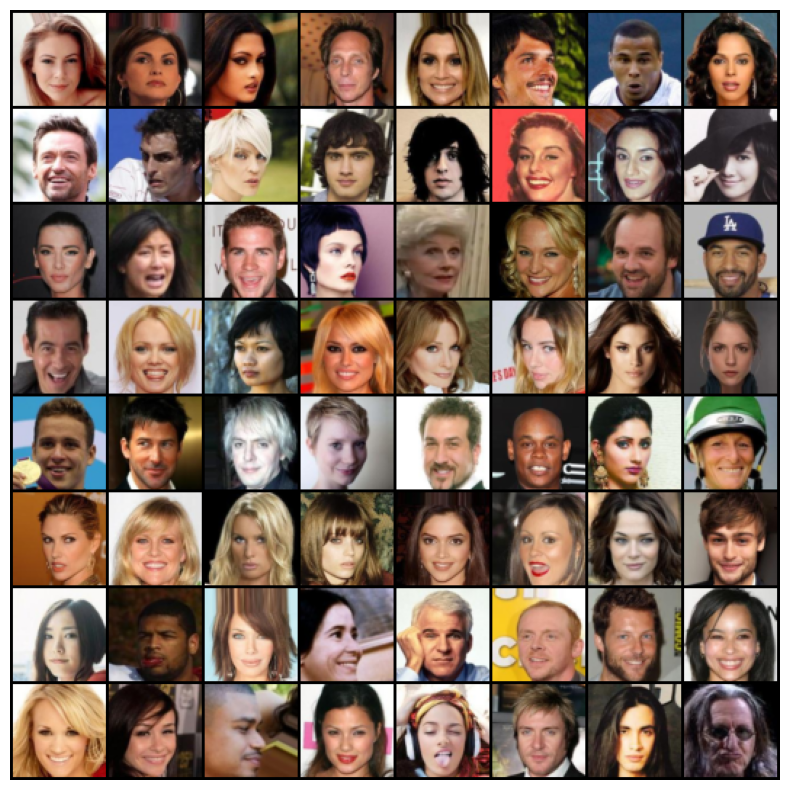

In [17]:
CelebADataset = torchvision.datasets.ImageFolder(
    root=dataset_folder,
    transform=transforms.Compose([
        transforms.CenterCrop(160),
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ])
)
# Create a DataLoader for the dataset
batch_size = 64
dataloader = DataLoader(
    CelebADataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4
)
# Check if the dataset is loaded correctly
print(f"Number of images in the dataset: {len(CelebADataset)}")
# Visualize some images from the dataset
def show_images(images, nrow=8):
    grid = torchvision.utils.make_grid(images, nrow=nrow, normalize=True)
    plt.figure(figsize=(10, 10))
    plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)))
    plt.axis('off')
    plt.show()
# Show a batch of images
for images, _ in dataloader:
    show_images(images)
    break

In [21]:
from celeba.utils.dataset import get_celeba_color_data
dataset, loader = get_celeba_color_data(batch_size=64, shuffle=False, with_label=False)

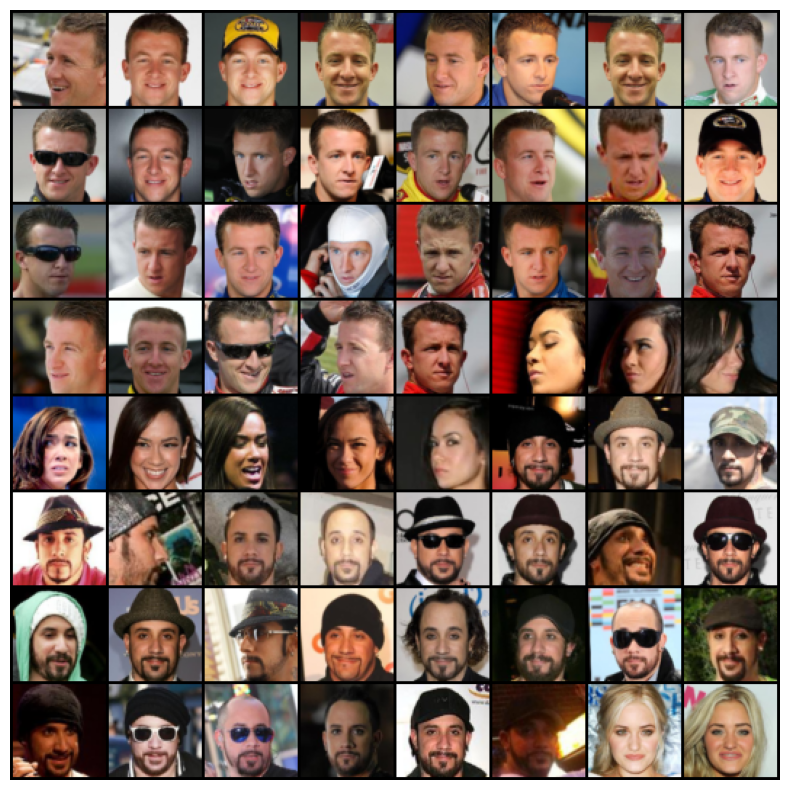

In [22]:
for images in loader:
    show_images(images)
    break